# D1-05 Uncertainty and Monte Carlo basics

This notebook introduces a practitioner-facing uncertainty workflow in `brightway` using the uncertainty information already present in the imported BAFU database.

We move from exchange-level uncertainty, to the `stats_arrays` data model, to stochastic LCIA scores and ranking robustness.

## Learning goals

- Find uncertainty information attached to exchanges in a real database.
- Connect Brightway exchange fields to the `stats_arrays` parameter-array format.
- Sample and visualize the uncertainty of a few individual exchanges.
- Run stochastic LCAs with `brightway` and summarize score distributions.
- Discuss how percentile overlap and a statistical test inform ranking robustness.
- Use a Sobol-style variance decomposition to identify dominant uncertainty drivers in a reduced model.
- Inject precomputed samples for selected exchanges while leaving the rest of the model stochastic.

## Background references

- Mutel, C. (2017). *Brightway: An open source framework for life cycle assessment*. Journal of Open Source Software, 2(12), 236. https://doi.org/10.21105/joss.00236
- `stats_arrays` documentation: https://stats-arrays.readthedocs.io/en/latest/

## 1) Load the imported BAFU database and choose two comparison activities

To stay close to `D1-04`, we compare two passenger-car operation activities already present in the BAFU workbook: one petrol car and one natural-gas car.

The impact category is climate change (`EF v3.1`, `GWP100`).

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from prettytable import PrettyTable
from scipy import stats
from stats_arrays import MCRandomNumberGenerator, UncertaintyBase, uncertainty_choices

import bw2calc as bc
import bw2data as bd
import bw_processing as bwp

pd.options.display.float_format = '{:,.3f}'.format

In [10]:
bd.projects.set_current('paris-lca-course-2026')
database_name = 'bafu'
method = ('EF v3.1', 'climate change', 'global warming potential (GWP100)')

In [4]:
petrol_car = [
    act for act in bd.Database("bafu")
    if all(
        x in act["name"].lower() for x in ("gasoline", "passenger car", "medium")
    )
    and act["unit"] == "kilometer"
    and act["location"] == "RER"
    and "fleet" not in act["name"]
][0]

ng_car = [
    act for act in bd.Database("bafu")
    if all(
        x in act["name"].lower() for x in ("compressed gas", "passenger car", "medium")
    )
    and act["unit"] == "kilometer"
    and act["location"] == "RER"
    and "fleet" not in act["name"]
    and "biomethane" not in act["name"]
][0]

In [5]:
[
    act for act in bd.Database("bafu")
    if all(
        x in act["name"].lower() for x in ("compressed gas", "passenger car", )
    )
    and act["unit"] == "kilometer"
    and act["location"] == "RER"
    and "fleet" not in act["name"]
    and "biomethane" not in act["name"]
]

['Transport, passenger car, compressed gas, Large, 2013, EURO-5' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Large SUV, 2008, EURO-4' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Medium, 2013, EURO-5' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Large SUV, 2013, EURO-5' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Large SUV, 2021, EURO-6d' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Compact, 2016, EURO-6ab' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Compact, 2019, EURO-6d-TEMP' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Medium, 2003, EURO-3' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Large, 2021, EURO-6d' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Large SUV, 2016, EURO-6ab' (kilometer, RER, None),
 'Transport, passenger car, compressed gas, Large, 2019, EURO-6d-TEMP' (kilo

In [6]:
petrol_car

'Transport, passenger car, plugin gasoline hybrid, Medium, 2016, EURO-6ab' (kilometer, RER, None)

In [7]:
ng_car

'Transport, passenger car, compressed gas, Medium, 2013, EURO-5' (kilometer, RER, None)

## 2) Inspect exchange uncertainty and the `stats_arrays` data model

Brightway stores uncertainty directly on exchanges, using fields such as `uncertainty type`, `loc`, `scale`, `minimum`, and `maximum`.

These fields follow the [`stats_arrays`](https://stats-arrays.readthedocs.io/en/latest/) convention.  

| Name                      | ID | loc          | scale       | shape | minimum            | maximum            |
| ------------------------- | -: | ------------ | ----------- | ----- | ------------------ | ------------------ |
| Undefined                 |  0 | static value |             |       |                    |                    |
| No uncertainty            |  1 | static value |             |       |                    |                    |
| Lognormal                 |  2 | mu           | sigma       |       | lower bound (opt.) | upper bound (opt.) |
| Normal                    |  3 | mu           | sigma       |       | lower bound (opt.) | upper bound (opt.) |
| Uniform                   |  4 |              |             |       | minimum            | maximum            |
| Triangular                |  5 | mode         |             |       | minimum            | maximum            |
| Bernoulli                 |  6 | p            |             |       | lower bound (opt.) | upper bound (opt.) |
| Discrete uniform          |  7 |              |             |       | minimum            | maximum            |
| Weibull                   |  8 | offset       | lambda      | k     |                    |                    |
| Gamma                     |  9 | offset       | theta       | k     |                    |                    |
| Beta                      | 10 | alpha        | upper bound | beta  |                    |                    |
| Generalized extreme value | 11 | mu           | sigma       | xi    |                    |                    |
| Student's t               | 12 | median       | scale       | nu    |                    |                    |


In [13]:
def pretty_number(value):
    if value is None or pd.isna(value):
        return None
    value = float(value)
    if value == 0:
        return '0'
    if abs(value) < 1e-3 or abs(value) >= 1e4:
        return f'{value:.3e}'
    return f'{value:.3f}'.rstrip('0').rstrip('.')


def uncertainty_name(uncertainty_type):
    cls = uncertainty_choices[int(uncertainty_type)]
    return cls.__name__.replace('Uncertainty', '')

In [14]:
print('First uncertain technosphere exchanges in the petrol car activity:')
rows = []
for exc in petrol_car.technosphere():
    data = exc.as_dict()
    uncertainty_type = data.get('uncertainty type')
    if uncertainty_type in (None, 0):
        continue
    rows.append({
        'input': exc.input['name'],
        'exchange type': data.get('type'),
        'amount': pretty_number(data.get('amount')),
        'distribution': uncertainty_name(uncertainty_type),
        'uncertainty type': int(uncertainty_type),
        'loc': pretty_number(data.get('loc')),
        'scale': pretty_number(data.get('scale')),
        'minimum': pretty_number(data.get('minimum')),
        'maximum': pretty_number(data.get('maximum')),
    })
pd.DataFrame(rows).head(10)

First uncertain technosphere exchanges in the petrol car activity:


,input,exchange type,amount,distribution,uncertainty type,loc,scale,minimum,maximum
0,"Brake wear emissions, passenger car",technosphere,8.060e-06,Lognormal,2,-11.729,0.242,None,None
1,"Disposal, road",technosphere,9.000e-04,Lognormal,2,-7.013,0.208,None,None
2,"Electricity, low voltage, production ENTSO-E, ...",technosphere,0.096,Lognormal,2,-2.343,0.038,None,None
3,Fuel supply for gasoline vehicles,technosphere,0.032,Lognormal,2,-3.433,0.016,None,None
4,"Maintenance, passenger car",technosphere,7.850e-06,Lognormal,2,-11.755,0.061,None,None
5,"Operation, maintenance, road",technosphere,0.001,Lognormal,2,-6.653,0.208,None,None
6,"Passenger car, plugin gasoline hybrid, Medium,...",technosphere,5.000e-06,Lognormal,2,-12.206,0.061,None,None
7,"Refrigerant R134a, at plant",technosphere,8.020e-06,Lognormal,2,-11.734,0.224,None,None
8,Road,technosphere,8.590e-04,Lognormal,2,-7.06,0.208,None,None
9,"Road wear emissions, passenger car",technosphere,1.600e-05,Lognormal,2,-11.043,0.242,None,None


In [15]:
print('First uncertain exchanges in the natural gas car activity:')
rows = []
for exc in petrol_car.biosphere():
    data = exc.as_dict()
    uncertainty_type = data.get('uncertainty type')
    if uncertainty_type in (None, 0):
        continue
    rows.append({
        'input': exc.input['name'],
        'exchange type': data.get('type'),
        'amount': pretty_number(data.get('amount')),
        'distribution': uncertainty_name(uncertainty_type),
        'uncertainty type': int(uncertainty_type),
        'loc': pretty_number(data.get('loc')),
        'scale': pretty_number(data.get('scale')),
        'minimum': pretty_number(data.get('minimum')),
        'maximum': pretty_number(data.get('maximum')),
    })
pd.DataFrame(rows).head(10)

First uncertain exchanges in the natural gas car activity:


,input,exchange type,amount,distribution,uncertainty type,loc,scale,minimum,maximum
0,1-Pentene,biosphere,1.210e-09,Lognormal,2,-20.533,0.036,None,None
1,1-Pentene,biosphere,4.140e-10,Lognormal,2,-21.605,0.036,None,None
2,1-Pentene,biosphere,1.850e-09,Lognormal,2,-20.108,0.036,None,None
3,Acetaldehyde,biosphere,9.640e-09,Lognormal,2,-18.457,0.036,None,None
4,Acetaldehyde,biosphere,3.310e-09,Lognormal,2,-19.526,0.036,None,None
5,Acetaldehyde,biosphere,1.480e-08,Lognormal,2,-18.029,0.036,None,None
6,Acetone,biosphere,7.230e-09,Lognormal,2,-18.745,0.036,None,None
7,Acetone,biosphere,2.480e-09,Lognormal,2,-19.815,0.036,None,None
8,Acetone,biosphere,1.110e-08,Lognormal,2,-18.316,0.036,None,None
9,Acrolein,biosphere,2.410e-09,Lognormal,2,-19.844,0.036,None,None


## 3) Sample a few exchange distributions directly

Before running full Monte Carlo LCAs, it is useful to look at the uncertainty of a few individual exchanges.

Here we stay at the exchange level and let `stats_arrays` sample three uncertain biosphere exchanges from the petrol car activity.

In [16]:
def pick_unique_uncertain_exchanges(activity, n=3):
    selected = []
    seen = set()
    for exc in activity.biosphere():
        data = exc.as_dict()
        if data.get('uncertainty type') in (None, 0):
            continue
        name = exc.input['name']
        if name in seen:
            continue
        seen.add(name)
        selected.append(exc)
        if len(selected) == n:
            break
    return selected


selected_exchanges = pick_unique_uncertain_exchanges(petrol_car, n=3)
selected_labels = [exc.input['name'] for exc in selected_exchanges]
selected_amounts = [exc.as_dict().get('amount') for exc in selected_exchanges]
selected_params = UncertaintyBase.from_dicts(*(exc.as_dict() for exc in selected_exchanges))

selected_table = pd.DataFrame.from_records(selected_params)
selected_table.insert(0, 'exchange', selected_labels)
selected_table.insert(1, 'amount', [pretty_number(x) for x in selected_amounts])
selected_table['distribution'] = selected_table['uncertainty_type'].map(lambda x: uncertainty_name(int(x)))
for column in ['loc', 'scale', 'shape', 'minimum', 'maximum']:
    selected_table[column] = selected_table[column].map(pretty_number)
display(selected_table[['exchange', 'amount', 'distribution', 'uncertainty_type', 'loc', 'scale', 'minimum', 'maximum']])

,exchange,amount,distribution,uncertainty_type,loc,scale,minimum,maximum
0,1-Pentene,1.210e-09,Lognormal,2,-20.533,0.036,None,None
1,Acetaldehyde,9.640e-09,Lognormal,2,-18.457,0.036,None,None
2,Acetone,7.230e-09,Lognormal,2,-18.745,0.036,None,None


In [17]:
selected_params

array([(-20.53264548, 0.03623573, nan, nan, nan, False, 2),
       (-18.45734473, 0.03623573, nan, nan, nan, False, 2),
       (-18.7450268 , 0.03623573, nan, nan, nan, False, 2)],
      dtype=[('loc', '<f8'), ('scale', '<f8'), ('shape', '<f8'), ('minimum', '<f8'), ('maximum', '<f8'), ('negative', '?'), ('uncertainty_type', 'u1')])

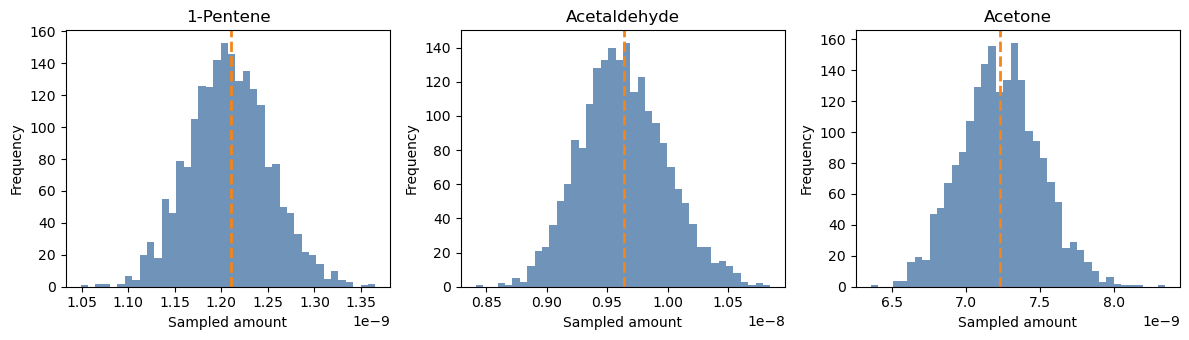

In [18]:
draws = 2000
rng = MCRandomNumberGenerator(selected_params)
samples = np.vstack([rng.next() for _ in range(draws)])

fig, axes = plt.subplots(1, len(selected_labels), figsize=(12, 3.5))
axes = np.atleast_1d(axes)

for idx, ax in enumerate(axes):
    ax.hist(samples[:, idx], bins=40, color='#4C78A8', alpha=0.8)
    ax.axvline(selected_amounts[idx], color='#F58518', linestyle='--', linewidth=2)
    ax.set_title(selected_labels[idx])
    ax.set_xlabel('Sampled amount')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4) Run stochastic LCAs in Brightway

Now we propagate uncertainty through the full inventory and impact assessment calculation.

`bw2calc.LCA` does stochastic LCA when `bc.LCA(..., use_distributions=True)` and repeated calls to `next(lca)`.

We also fix the random seed so everyone in the course sees the same Monte Carlo sequence.

In [22]:
def stochastic_scores(fu, method, iterations=300, seed=1234):
    lca = bc.LCA(
        fu,
        method=method,
        use_distributions=True,
        seed_override=seed,
    )
    lca.lci()
    lca.lcia()

    scores = [lca.score]
    for _ in range(iterations - 1):
        next(lca)
        scores.append(lca.score)

    return np.array(scores, dtype=float)

In [23]:
iterations = 300
seed = 1234

petrol_scores = stochastic_scores({petrol_car: 1}, method, iterations=iterations, seed=seed)
gas_scores = stochastic_scores({ng_car: 1}, method, iterations=iterations, seed=seed)

summary = pd.DataFrame([
    {
        'activity': 'Petrol car',
        'mean': petrol_scores.mean(),
        'std': petrol_scores.std(ddof=1),
        'p05': np.percentile(petrol_scores, 5),
        'p50': np.percentile(petrol_scores, 50),
        'p95': np.percentile(petrol_scores, 95),
    },
    {
        'activity': 'Natural gas car',
        'mean': gas_scores.mean(),
        'std': gas_scores.std(ddof=1),
        'p05': np.percentile(gas_scores, 5),
        'p50': np.percentile(gas_scores, 50),
        'p95': np.percentile(gas_scores, 95),
    },
])

print(f'Random seed used: {seed}')
display(summary)

Random seed used: 1234


,activity,mean,std,p05,p50,p95
0,Petrol car,0.240,0.009,0.227,0.239,0.256
1,Natural gas car,0.265,0.013,0.245,0.265,0.289


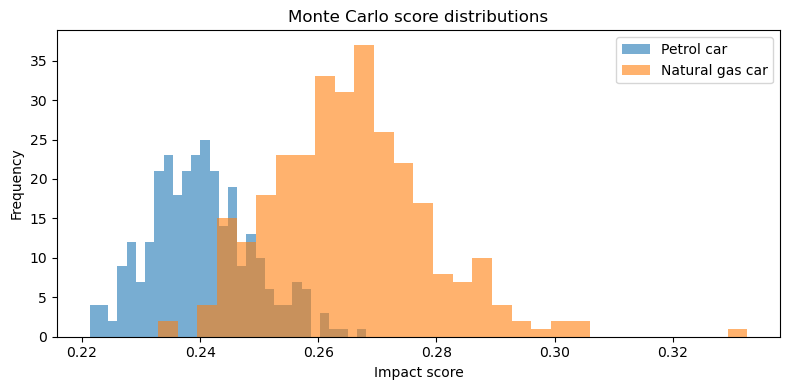

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(petrol_scores, bins=30, alpha=0.6, label='Petrol car')
plt.hist(gas_scores, bins=30, alpha=0.6, label='Natural gas car')
plt.xlabel('Impact score')
plt.ylabel('Frequency')
plt.title('Monte Carlo score distributions')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
petrol_car

'Transport, passenger car, plugin gasoline hybrid, Medium, 2016, EURO-6ab' (kilometer, RER, None)

In [25]:
ng_car

'Transport, passenger car, compressed gas, Medium, 2013, EURO-5' (kilometer, RER, None)

## 5) Compare percentiles and ranking robustness

A first practical check is to compare percentile ranges.

For climate change, lower scores are better. So we also calculate the probability that the natural-gas car scores lower than the petrol car in a random pair of Monte Carlo draws.

In [26]:

interval_table = pd.DataFrame([
    {
        'activity': 'Petrol car',
        'p05': np.percentile(petrol_scores, 5),
        'p50': np.percentile(petrol_scores, 50),
        'p95': np.percentile(petrol_scores, 95),
    },
    {
        'activity': 'Natural gas car',
        'p05': np.percentile(gas_scores, 5),
        'p50': np.percentile(gas_scores, 50),
        'p95': np.percentile(gas_scores, 95),
    },
])

intervals_overlap = not (
    interval_table.loc[0, 'p95'] < interval_table.loc[1, 'p05']
    or interval_table.loc[1, 'p95'] < interval_table.loc[0, 'p05']
)
probability_gas_better = (gas_scores[:, None] < petrol_scores[None, :]).mean()

display(interval_table)
print('Do the 5th-95th percentile intervals overlap?', intervals_overlap)
print(f'Probability that natural gas scores lower than petrol: {probability_gas_better:.3f}')

,activity,p05,p50,p95
0,Petrol car,0.227,0.239,0.256
1,Natural gas car,0.245,0.265,0.289


Do the 5th-95th percentile intervals overlap? True
Probability that natural gas scores lower than petrol: 0.048


## 6) Add a statistical test

One possible next step is a Mann-Whitney U test.

This non-parametric test checks whether the two score distributions are shifted relative to one another, without assuming normality. It should be read together with the overlap and the probability-of-superiority result above, not in isolation.

In [27]:
mw_result = stats.mannwhitneyu(petrol_scores, gas_scores, alternative='two-sided')

print(f'Mann-Whitney U statistic: {mw_result.statistic:,.0f}')
print(f'p-value: {mw_result.pvalue:.4f}')

if mw_result.pvalue < 0.05:
    print('The distributions are statistically shifted.')
else:
    print('The test does not show a clear shift between the distributions.')


Mann-Whitney U statistic: 4,343
p-value: 0.0000
The distributions are statistically shifted.


The petrol car option shows a slightly lower median impact than petrol, and the sampled distributions differ statistically; however, the uncertainty intervals overlap strongly and the probability of natural gas outperforming petrol is still above 10%, indicating limited practical confidence in the ranking.

## 7) Paired stochastic LCA

With possibly shared uncertain parameters, a paired comparison might be more appropriate

In [28]:
iterations = 300
seed = 1234

diff_scores = stochastic_scores(
    {petrol_car: 1, ng_car: -1}, # we run the delta of the two systems
    method, 
    iterations=iterations, 
    seed=seed
)

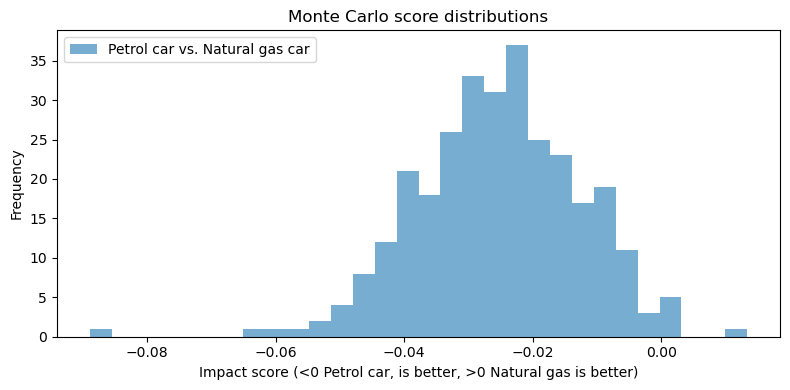

In [29]:
plt.figure(figsize=(8, 4))
plt.hist(diff_scores, bins=30, alpha=0.6, label='Petrol car vs. Natural gas car')
plt.xlabel('Impact score (<0 Petrol car, is better, >0 Natural gas is better)')
plt.ylabel('Frequency')
plt.title('Monte Carlo score distributions')
plt.legend()
plt.tight_layout()
plt.show()

## 8) Bonus: a Sobol-style variance decomposition

A full Sobol analysis of all uncertain Brightway exchanges would need a more elaborate parameterization workflow.

Here we do something lighter and still useful: we isolate the uncertain **direct biosphere exchanges** of the petrol-car activity that have a non-zero climate-change characterization factor, and we keep all other model elements fixed.

Because this reduced score model is additive and the selected inputs are sampled independently, the first-order and total-order Sobol indices are the same. In this special case, they reduce to simple variance shares.

In [30]:
static_lca = bc.LCA({petrol_car: 1}, method=method)
static_lca.lci()
static_lca.lcia()

petrol_index = static_lca.dicts.activity[petrol_car.id]
petrol_supply = float(static_lca.supply_array[petrol_index])

climate_relevant_exchanges = []
climate_rows = []
for exc in petrol_car.biosphere():
    data = exc.as_dict()
    if data.get('uncertainty type') in (None, 0):
        continue
    row = static_lca.dicts.biosphere[exc.input.id]
    cf = float(static_lca.characterization_matrix[row, row])
    if cf == 0:
        continue
    climate_relevant_exchanges.append(exc)
    direct_score = petrol_supply * data.get('amount') * cf
    climate_rows.append({
        'exchange': exc.input['name'],
        'amount': pretty_number(data.get('amount')),
        'CF': pretty_number(cf),
        'direct score at mean': pretty_number(direct_score),
        '_direct_score_sort': direct_score,
        'distribution': uncertainty_name(data.get('uncertainty type')),
    })

climate_exchange_table = pd.DataFrame(climate_rows)
climate_exchange_table = climate_exchange_table.sort_values('_direct_score_sort', ascending=False)
display(climate_exchange_table.drop(columns='_direct_score_sort'))

,exchange,amount,CF,direct score at mean,distribution
3,"Carbon dioxide, fossil",0.097,1,0.097,Lognormal
10,"1,1,1,2-Tetrafluoroethane",4.630e-06,1530,0.007,Lognormal
4,Dinitrogen monoxide,7.770e-08,273,2.121e-05,Lognormal
11,"Methane, fossil",5.800e-07,29.8,1.728e-05,Lognormal
5,Dinitrogen monoxide,2.330e-08,273,6.361e-06,Lognormal
13,"Methane, fossil",1.950e-07,29.8,5.811e-06,Lognormal
12,"Methane, fossil",1.740e-07,29.8,5.185e-06,Lognormal
6,Dinitrogen monoxide,1.480e-08,273,4.040e-06,Lognormal
9,Ethane,5.900e-08,0.437,2.578e-08,Lognormal
7,Ethane,3.860e-08,0.437,1.687e-08,Lognormal


In [32]:
def transform_unit_cube(params, unit_cube):
    transformed = np.zeros_like(unit_cube)
    for column in range(params.shape[0]):
        distribution = uncertainty_choices[int(params['uncertainty_type'][column])]
        transformed[:, column] = distribution.ppf(
            params[column:column + 1],
            unit_cube[:, column].reshape(1, -1),
        ).reshape(-1)
    return transformed



climate_params = UncertaintyBase.from_dicts(*(exc.as_dict() for exc in climate_relevant_exchanges))
climate_labels = [exc.input['name'] for exc in climate_relevant_exchanges]
climate_cf = np.array([
    float(static_lca.characterization_matrix[static_lca.dicts.biosphere[exc.input.id], static_lca.dicts.biosphere[exc.input.id]])
    for exc in climate_relevant_exchanges
])

sobol_draws = 50000
sobol_seed = 1234
rng = np.random.default_rng(sobol_seed)
unit_cube = rng.random((sobol_draws, climate_params.shape[0]))
sampled_amounts = transform_unit_cube(climate_params, unit_cube)

direct_terms = petrol_supply * sampled_amounts * climate_cf
direct_scores = direct_terms.sum(axis=1)
total_variance = direct_scores.var(ddof=1)

sobol_table = pd.DataFrame({
    'exchange': climate_labels,
    'S1': direct_terms.var(axis=0, ddof=1) / total_variance,
}).sort_values('S1', ascending=False)
sobol_table['ST'] = sobol_table['S1']

sobol_display_table = sobol_table.copy()
sobol_display_table['S1'] = sobol_display_table['S1'].map(pretty_number)
sobol_display_table['ST'] = sobol_display_table['ST'].map(pretty_number)

print(f'Sobol seed: {sobol_seed}, draws: {sobol_draws}')
display(sobol_display_table)
print(f"Sum of first-order indices: {sobol_table['S1'].sum():.3f}")

Sobol seed: 1234, draws: 50000


,exchange,S1,ST
3,"Carbon dioxide, fossil",0.995,0.995
10,"1,1,1,2-Tetrafluoroethane",0.005,0.005
4,Dinitrogen monoxide,4.621e-08,4.621e-08
11,"Methane, fossil",3.086e-08,3.086e-08
5,Dinitrogen monoxide,4.174e-09,4.174e-09
13,"Methane, fossil",3.497e-09,3.497e-09
12,"Methane, fossil",2.808e-09,2.808e-09
6,Dinitrogen monoxide,1.703e-09,1.703e-09
9,Ethane,6.891e-14,6.891e-14
7,Ethane,2.953e-14,2.953e-14


Sum of first-order indices: 1.000


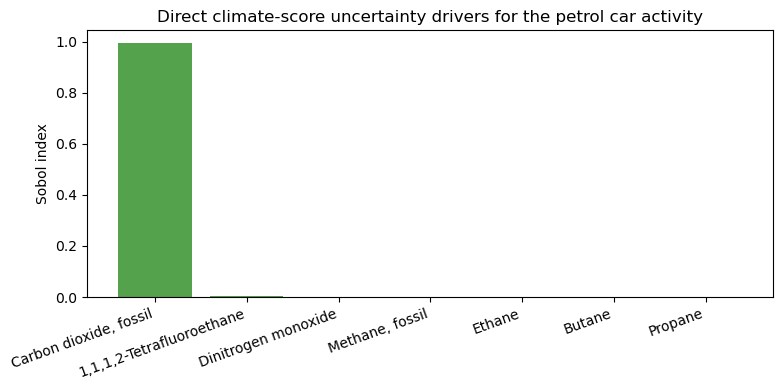

In [33]:
plt.figure(figsize=(8, 4))
plt.bar(sobol_table['exchange'], sobol_table['S1'], color='#54A24B')
plt.ylabel('Sobol index')
plt.title('Direct climate-score uncertainty drivers for the petrol car activity')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 9) Bonus: precomputed paired samples for selected exchanges

Sometimes we want more control than standard Monte Carlo for a few key exchanges.

Here we precompute structured pseudo-random samples for the **fuel input** of both passenger-car activities, and we derive the corresponding **fossil CO2 emission** from each sampled fuel amount. We then inject these four sample series back into Brightway with `add_persistent_array(...)`.

The key point is that only these four matrix entries are overwritten. All other uncertain exchanges keep their original `brightway` / `stats_arrays` uncertainty distributions because we still run the LCA with `use_distributions=True`.

In [34]:
def sample_exchange_from_unit_interval(exchange, unit_interval):
    params = UncertaintyBase.from_dicts(exchange.as_dict())
    distribution = uncertainty_choices[int(params['uncertainty_type'][0])]
    return distribution.ppf(params, unit_interval.reshape(1, -1)).reshape(-1)


# we create references to the technosphere exchanges of interest
petrol_fuel_exc = next(exc for exc in petrol_car.technosphere() if 'Fuel supply' in exc.input['name'])
gas_fuel_exc = next(exc for exc in ng_car.technosphere() if 'Fuel supply' in exc.input['name'])

# same for the biosphere exchanges
petrol_co2_exc = next(exc for exc in petrol_car.biosphere() if exc.input['name'] == 'Carbon dioxide, fossil')
gas_co2_exc = next(exc for exc in ng_car.biosphere() if exc.input['name'] == 'Carbon dioxide, fossil')
petrol_ammonia_exc = next(exc for exc in petrol_car.biosphere() if exc.input['name'] == 'Ammonia')

paired_iterations = 300
paired_seed = 2026
paired_u = (np.arange(paired_iterations) + 0.5) / paired_iterations
rng = np.random.default_rng(paired_seed)
rng.shuffle(paired_u)

petrol_fuel_samples = sample_exchange_from_unit_interval(petrol_fuel_exc, paired_u)
gas_fuel_samples = sample_exchange_from_unit_interval(gas_fuel_exc, paired_u)

petrol_co2_factor = petrol_co2_exc.as_dict()['amount'] / petrol_fuel_exc.as_dict()['amount']
gas_co2_factor = gas_co2_exc.as_dict()['amount'] / gas_fuel_exc.as_dict()['amount']

petrol_co2_samples = petrol_co2_factor * petrol_fuel_samples
gas_co2_samples = gas_co2_factor * gas_fuel_samples

paired_preview = pd.DataFrame({
    'petrol fuel sample': [pretty_number(x) for x in petrol_fuel_samples[:5]],
    'petrol CO2 sample': [pretty_number(x) for x in petrol_co2_samples[:5]],
    'natural gas sample': [pretty_number(x) for x in gas_fuel_samples[:5]],
    'natural gas CO2 sample': [pretty_number(x) for x in gas_co2_samples[:5]],
})

print(f'Paired sample seed: {paired_seed}, iterations: {paired_iterations}')
display(paired_preview)

Paired sample seed: 2026, iterations: 300


,petrol fuel sample,petrol CO2 sample,natural gas sample,natural gas CO2 sample
0,0.032,0.096,0.052,0.126
1,0.032,0.095,0.051,0.125
2,0.032,0.098,0.053,0.128
3,0.032,0.096,0.052,0.125
4,0.033,0.099,0.053,0.129


In [35]:
# we create a data package for bw2calc to consume
dp_paired = bwp.create_datapackage(sequential=True)

# we add peristent arrays without our pre-computed values we want to iterate over
dp_paired.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(petrol_fuel_exc.input.id, petrol_car.id)], dtype=bwp.INDICES_DTYPE),
    data_array=petrol_fuel_samples.reshape((1, -1)),
    flip_array=np.array([True]),
    name='petrol-fuel-override',
)
dp_paired.add_persistent_array(
    matrix='biosphere_matrix',
    indices_array=np.array([(petrol_co2_exc.input.id, petrol_car.id)], dtype=bwp.INDICES_DTYPE),
    data_array=petrol_co2_samples.reshape((1, -1)),
    name='petrol-co2-override',
)
dp_paired.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(gas_fuel_exc.input.id, ng_car.id)], dtype=bwp.INDICES_DTYPE),
    data_array=gas_fuel_samples.reshape((1, -1)),
    flip_array=np.array([True]),
    name='gas-fuel-override',
)
dp_paired.add_persistent_array(
    matrix='biosphere_matrix',
    indices_array=np.array([(gas_co2_exc.input.id, ng_car.id)], dtype=bwp.INDICES_DTYPE),
    data_array=gas_co2_samples.reshape((1, -1)),
    name='gas-co2-override',
)

petrol_demand, petrol_data_objs, petrol_remapping = bd.prepare_lca_inputs(demand={petrol_car: 1}, method=method)
gas_demand, gas_data_objs, gas_remapping = bd.prepare_lca_inputs(demand={ng_car: 1}, method=method)

# we create our LCA objects
petrol_controlled_lca = bc.LCA(
    petrol_demand,
    data_objs=petrol_data_objs + [dp_paired],
    remapping_dicts=petrol_remapping,
    use_distributions=True,
    use_arrays=True,
)
gas_controlled_lca = bc.LCA(
    gas_demand,
    data_objs=gas_data_objs + [dp_paired],
    remapping_dicts=gas_remapping,
    use_distributions=True,
    use_arrays=True,
)
petrol_controlled_lca.lci()
petrol_controlled_lca.lcia()
gas_controlled_lca.lci()
gas_controlled_lca.lcia()

In [36]:
# we build a nice table to keep track of the exchange values used
petrol_fuel_row = petrol_controlled_lca.dicts.product[petrol_fuel_exc.input.id]
petrol_activity_col = petrol_controlled_lca.dicts.activity[petrol_car.id]
petrol_co2_row = petrol_controlled_lca.dicts.biosphere[petrol_co2_exc.input.id]
petrol_ammonia_row = petrol_controlled_lca.dicts.biosphere[petrol_ammonia_exc.input.id]

gas_fuel_row = gas_controlled_lca.dicts.product[gas_fuel_exc.input.id]
gas_activity_col = gas_controlled_lca.dicts.activity[ng_car.id]
gas_co2_row = gas_controlled_lca.dicts.biosphere[gas_co2_exc.input.id]

paired_records = []
for step in range(paired_iterations):
    paired_records.append({
        'iteration': step,
        'petrol fuel': -float(petrol_controlled_lca.technosphere_matrix[petrol_fuel_row, petrol_activity_col]),
        'petrol fossil CO2': float(petrol_controlled_lca.biosphere_matrix[petrol_co2_row, petrol_activity_col]),
        'petrol ammonia': float(petrol_controlled_lca.biosphere_matrix[petrol_ammonia_row, petrol_activity_col]),
        'petrol score': float(petrol_controlled_lca.score),
        'natural gas fuel': -float(gas_controlled_lca.technosphere_matrix[gas_fuel_row, gas_activity_col]),
        'natural gas fossil CO2': float(gas_controlled_lca.biosphere_matrix[gas_co2_row, gas_activity_col]),
        'natural gas score': float(gas_controlled_lca.score),
    })
    if step < paired_iterations - 1:
        next(petrol_controlled_lca)
        next(gas_controlled_lca)

paired_results = pd.DataFrame(paired_records)
paired_display = paired_results.head(6).copy()
for column in paired_display.columns[1:]:
    paired_display[column] = paired_display[column].map(pretty_number)
display(paired_display)

petrol_pairing_ok = np.allclose(
    paired_results['petrol fossil CO2'] / paired_results['petrol fuel'],
    petrol_co2_factor,
)
gas_pairing_ok = np.allclose(
    paired_results['natural gas fossil CO2'] / paired_results['natural gas fuel'],
    gas_co2_factor,
)
untouched_exchange_varies = paired_results['petrol ammonia'].nunique() > 1

print('Did the petrol fuel / CO2 pairing stay fixed?', petrol_pairing_ok)
print('Did the natural-gas fuel / CO2 pairing stay fixed?', gas_pairing_ok)
print('Did an untouched exchange still vary?', untouched_exchange_varies)
print('This means only the selected fuel and CO2 exchanges were overwritten; the other uncertain exchanges still use their original distributions.')

,iteration,petrol fuel,petrol fossil CO2,petrol ammonia,petrol score,natural gas fuel,natural gas fossil CO2,natural gas score
0,0,0.032,0.096,6.406e-06,0.248,0.052,0.126,0.256
1,1,0.032,0.095,6.708e-06,0.233,0.051,0.125,0.269
2,2,0.032,0.098,6.549e-06,0.244,0.053,0.128,0.296
3,3,0.032,0.096,6.167e-06,0.249,0.052,0.125,0.306
4,4,0.033,0.099,6.530e-06,0.239,0.053,0.129,0.246
5,5,0.033,0.101,6.278e-06,0.252,0.054,0.132,0.258


Did the petrol fuel / CO2 pairing stay fixed? True
Did the natural-gas fuel / CO2 pairing stay fixed? True
Did an untouched exchange still vary? True
This means only the selected fuel and CO2 exchanges were overwritten; the other uncertain exchanges still use their original distributions.


In [37]:
paired_results

,iteration,petrol fuel,petrol fossil CO2,petrol ammonia,petrol score,natural gas fuel,natural gas fossil CO2,natural gas score
0,0,0.032,0.096,0.000,0.248,0.052,0.126,0.256
1,1,0.032,0.095,0.000,0.233,0.051,0.125,0.269
2,2,0.032,0.098,0.000,0.244,0.053,0.128,0.296
3,3,0.032,0.096,0.000,0.249,0.052,0.125,0.306
4,4,0.033,0.099,0.000,0.239,0.053,0.129,0.246
...,...,...,...,...,...,...,...,...
295,295,0.032,0.095,0.000,0.233,0.051,0.125,0.255
296,296,0.032,0.097,0.000,0.219,0.052,0.127,0.281
297,297,0.033,0.098,0.000,0.236,0.053,0.129,0.267
298,298,0.032,0.098,0.000,0.228,0.053,0.128,0.267


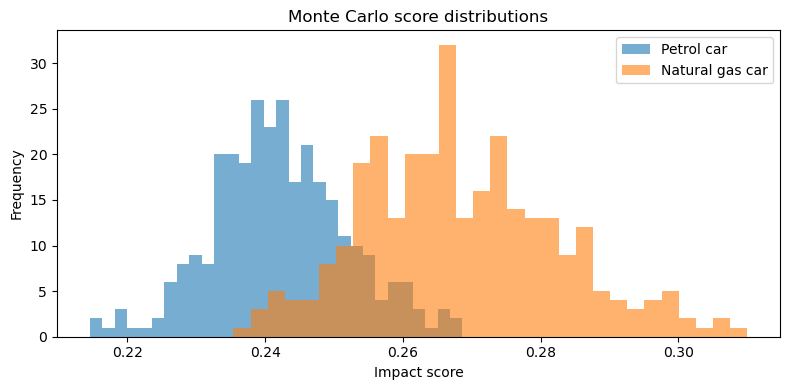

In [38]:
plt.figure(figsize=(8, 4))
plt.hist(paired_results["petrol score"], bins=30, alpha=0.6, label='Petrol car')
plt.hist(paired_results["natural gas score"], bins=30, alpha=0.6, label='Natural gas car')
plt.xlabel('Impact score')
plt.ylabel('Frequency')
plt.title('Monte Carlo score distributions')
plt.legend()
plt.tight_layout()
plt.show()

We do not necessarily have a better answer than before, but we now know that the carbon balance in both transport activities is respected.

## Recap

After this notebook, you should now be able to:

- connect Brightway uncertainty fields to the `stats_arrays` parameter-array format
- inspect and sample uncertainty for individual exchanges
- run stochastic LCAs in `brightway`
- summarize score distributions with percentiles and histograms
- explain why overlap, probability of superiority, and a statistical test should be read together
- identify the dominant uncertainty drivers in a reduced Sobol-style analysis
- inject precomputed samples for selected exchanges while preserving the uncertainty of the other exchanges